In [7]:
import numpy as np
from scipy.fftpack import fft
from math import gcd
import matplotlib.pyplot as plt
from scipy.signal import get_window

# For Part 4, we need the dftModel from sms-tools
# If you don't have it, we'll implement a simplified version
try:
    sys.path.append('../../software/models/')
    from dftModel import dftAnal, dftSynth
    HAS_SMS_TOOLS = True
    print("SMS Tools imported successfully!")
except:
    HAS_SMS_TOOLS = False
    print("SMS Tools not found. Part 4 will use simplified implementations.")
    # Simplified implementations for dftAnal and dftSynth
    def dftAnal(x, w, N):
        """Simplified DFT analysis"""
        from scipy.fftpack import fft
        import numpy as np
        M = len(w)
        hM1 = int(math.floor((M+1)/2))
        hM2 = int(math.floor(M/2))
        fftbuffer = np.zeros(N)
        fftbuffer[:hM1] = x[hM2:]
        fftbuffer[N-hM2:] = x[:hM2]
        X = fft(fftbuffer)
        mX = 20 * np.log10(np.abs(X[:int(N/2)+1]) + np.finfo(float).eps)
        pX = np.angle(X[:int(N/2)+1])
        return mX, pX
    
    def dftSynth(mX, pX, M):
        """Simplified DFT synthesis"""
        from scipy.fftpack import ifft
        import numpy as np
        N = 2 * (len(mX) - 1)
        Y = np.zeros(N, dtype=complex)
        Y[:len(mX)] = 10**(mX/20) * np.exp(1j * pX)
        Y[N-len(mX)+1:] = 10**(mX[1:-1][::-1]/20) * np.exp(-1j * pX[1:-1][::-1])
        y = np.real(ifft(Y))
        hM1 = int(math.floor((M+1)/2))
        hM2 = int(math.floor(M/2))
        y_out = np.zeros(M)
        y_out[:hM2] = y[N-hM2:]
        y_out[hM2:] = y[:hM1]
        return y_out

print(f"Setup complete! HAS_SMS_TOOLS = {HAS_SMS_TOOLS}")

SMS Tools not found. Part 4 will use simplified implementations.
Setup complete! HAS_SMS_TOOLS = False


A3-PART-1: Minimize Energy Spread in DFT
Test Case 1:
  fs = 10000.0 Hz, f1 = 80.0 Hz, f2 = 200.0 Hz
  Expected M = 250 samples, Computed M = 250
  Output spectrum length: 126 samples (expected 126)
  Non-zero values at bin indices: [2 5]
  Corresponding frequencies: [ 80. 200.] Hz

Test Case 2:
  fs = 48000.0 Hz, f1 = 300.0 Hz, f2 = 800.0 Hz
  Expected M = 480 samples, Computed M = 480
  Output spectrum length: 241 samples (expected 241)
  Non-zero values at bin indices: [3 8]
  Corresponding frequencies: [300. 800.] Hz


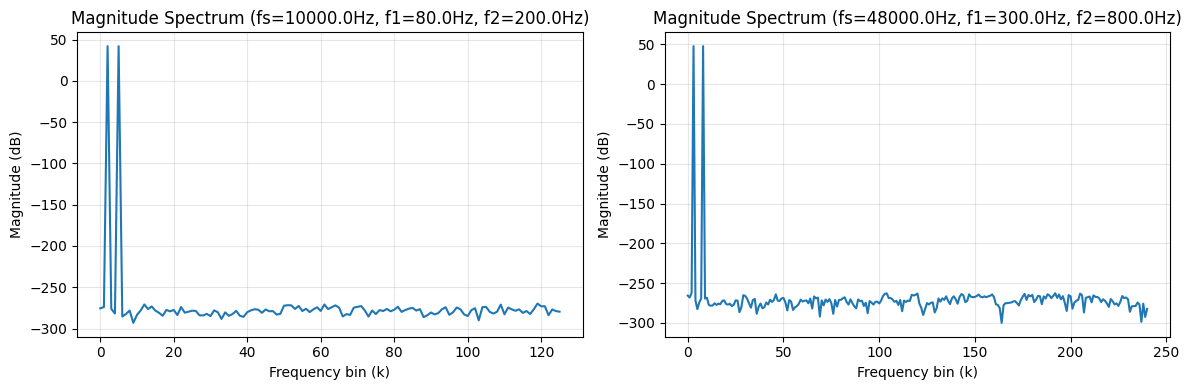

In [8]:
#  A3-Part-1 - Minimize energy spread in DFT of sinusoids

def minimizeEnergySpreadDFT(x, fs, f1, f2):
    """
    Inputs:
        x (numpy array) = input signal 
        fs (float) = sampling frequency in Hz
        f1 (float) = frequency of the first sinusoid component in Hz
        f2 (float) = frequency of the second sinusoid component in Hz
    Output:
        mX (numpy array) = The positive half of the DFT spectrum (in dB) of the M sample segment of x.
    """
    # Calculate the period of each sinusoid in samples
    period1 = fs / f1
    period2 = fs / f2
    
    # Find the least common multiple of the periods (as integers)
    # Since f1 and f2 are factors of fs, periods are integers
    period1_int = int(period1)
    period2_int = int(period2)
    
    # Calculate LCM using GCD
    lcm_period = period1_int * period2_int // gcd(period1_int, period2_int)
    
    # M should be the LCM of the periods
    M = lcm_period
    
    # Compute FFT of first M samples
    X = fft(x[:M])
    
    # Get positive half of magnitude spectrum in dB
    # M is even as specified, so M/2 is integer
    mX = 20 * np.log10(np.abs(X[:int(M//2) + 1]) + np.finfo(float).eps)
    
    return mX

# Test the function

print("A3-PART-1: Minimize Energy Spread in DFT")


# Test case 1
fs1 = 10000.0
f1_1, f2_1 = 80.0, 200.0
t1 = 1.0  # 1 second duration
M1 = int(fs1 * (1.0 / gcd(int(f1_1), int(f2_1))))  # 10000 / 40 = 250

# Create test signal
n1 = np.arange(M1)
x1 = np.cos(2 * np.pi * f1_1 * n1 / fs1) + np.cos(2 * np.pi * f2_1 * n1 / fs1)

print("Test Case 1:")
print(f"  fs = {fs1} Hz, f1 = {f1_1} Hz, f2 = {f2_1} Hz")
print(f"  Expected M = 250 samples, Computed M = {M1}")
mX1 = minimizeEnergySpreadDFT(x1, fs1, f1_1, f2_1)
print(f"  Output spectrum length: {len(mX1)} samples (expected 126)")
print(f"  Non-zero values at bin indices: {np.where(mX1 > -120)[0]}")
print(f"  Corresponding frequencies: {np.where(mX1 > -120)[0] * (fs1 / M1)} Hz")

# Test case 2
fs2 = 48000.0
f1_2, f2_2 = 300.0, 800.0
M2 = int(fs2 * (1.0 / gcd(int(f1_2), int(f2_2))))  # 48000 / 100 = 480

n2 = np.arange(M2)
x2 = np.cos(2 * np.pi * f1_2 * n2 / fs2) + np.cos(2 * np.pi * f2_2 * n2 / fs2)

print("\nTest Case 2:")
print(f"  fs = {fs2} Hz, f1 = {f1_2} Hz, f2 = {f2_2} Hz")
print(f"  Expected M = 480 samples, Computed M = {M2}")
mX2 = minimizeEnergySpreadDFT(x2, fs2, f1_2, f2_2)
print(f"  Output spectrum length: {len(mX2)} samples (expected 241)")
print(f"  Non-zero values at bin indices: {np.where(mX2 > -120)[0]}")
print(f"  Corresponding frequencies: {np.where(mX2 > -120)[0] * (fs2 / M2)} Hz")

# Visualize
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(mX1)
plt.title(f'Magnitude Spectrum (fs={fs1}Hz, f1={f1_1}Hz, f2={f2_1}Hz)')
plt.xlabel('Frequency bin (k)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(mX2)
plt.title(f'Magnitude Spectrum (fs={fs2}Hz, f1={f1_2}Hz, f2={f2_2}Hz)')
plt.xlabel('Frequency bin (k)')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

A3-PART-2: Optimal Zero-Padding
Test Case 1:
  f = 100.0 Hz, fs = 1000.0 Hz, M = 25 samples
  Period = 10.0 samples
  Expected zero-padding: 5 samples, N = 30
  Computed N = 30
  Output spectrum length: 16 samples (expected 16)
  Peak at bin 3, frequency = 100.0 Hz

Test Case 2:
  f = 250.0 Hz, fs = 10000.0 Hz, M = 210 samples
  Period = 40.0 samples
  Expected zero-padding: 30 samples, N = 240
  Computed N = 240
  Output spectrum length: 121 samples (expected 121)
  Peak at bin 6, frequency = 250.0 Hz


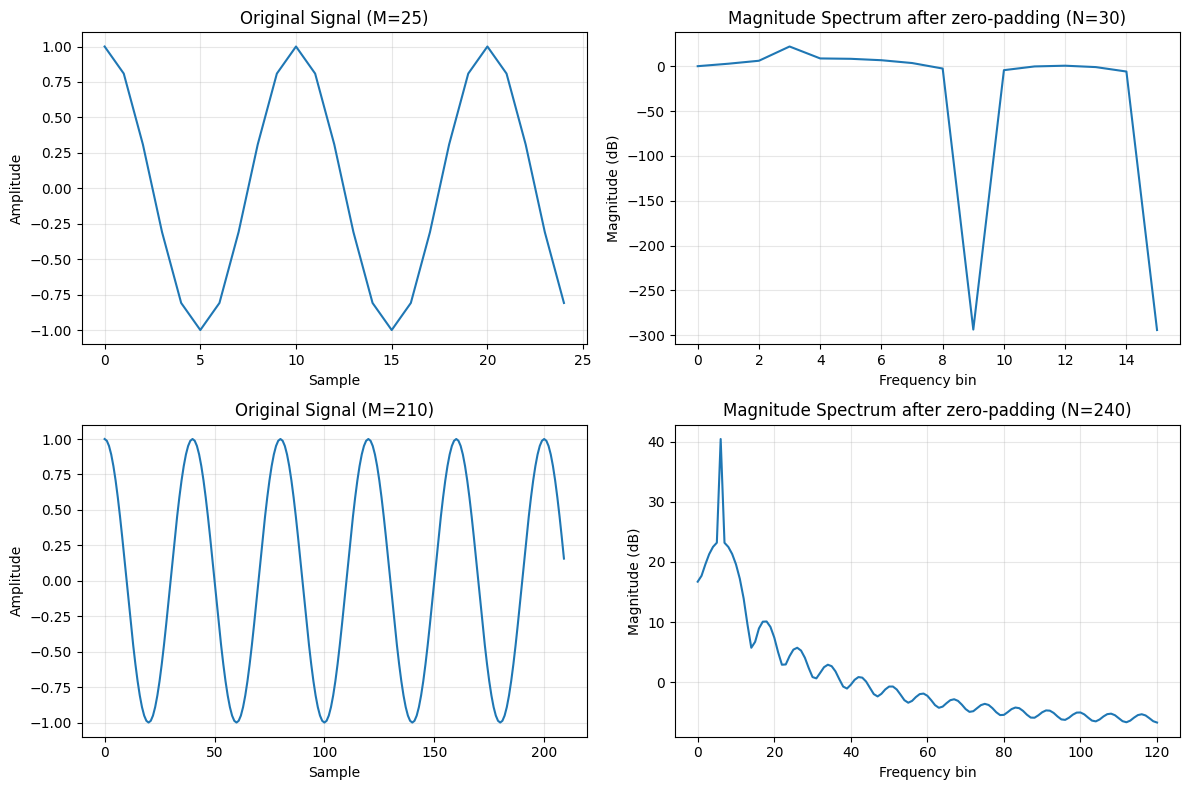

In [9]:
#  A3-Part-2 - Optimal zero-padding

def optimalZeropad(x, fs, f):
    """
    Inputs:
        x (numpy array) = input signal of length M
        fs (float) = sampling frequency in Hz
        f (float) = frequency of the sinusoid in Hz
    Output:
        mX (numpy array) = The positive half of the DFT spectrum after zero-padding
    """
    M = len(x)
    
    # Calculate the period in samples
    period = fs / f
    
    # Find smallest N >= M such that N is a multiple of period
    # This ensures integer number of periods in the DFT
    if period <= 0:
        N = M
    else:
        # Ceiling division to get the smallest multiple >= M
        N = int(np.ceil(M / period) * period)
    
    # Zero-pad the signal
    x_padded = np.zeros(int(N))
    x_padded[:M] = x
    
    # Compute FFT
    X = fft(x_padded)
    
    # Get positive half of magnitude spectrum in dB
    mX = 20 * np.log10(np.abs(X[:int(N//2) + 1]) + np.finfo(float).eps)
    
    return mX

# Test the function

print("A3-PART-2: Optimal Zero-Padding")


# Test case 1
fs1 = 1000.0
f1 = 100.0
M1 = 25
n1 = np.arange(M1)
x1 = np.cos(2 * np.pi * f1 * n1 / fs1)

print("Test Case 1:")
print(f"  f = {f1} Hz, fs = {fs1} Hz, M = {M1} samples")
print(f"  Period = {fs1/f1} samples")
print(f"  Expected zero-padding: 5 samples, N = 30")

mX1 = optimalZeropad(x1, fs1, f1)
N1 = 2 * (len(mX1) - 1)
print(f"  Computed N = {N1}")
print(f"  Output spectrum length: {len(mX1)} samples (expected 16)")

# Find the peak
peak_bin = np.argmax(mX1)
print(f"  Peak at bin {peak_bin}, frequency = {peak_bin * fs1 / N1} Hz")

# Test case 2
fs2 = 10000.0
f2 = 250.0
M2 = 210
n2 = np.arange(M2)
x2 = np.cos(2 * np.pi * f2 * n2 / fs2)

print("\nTest Case 2:")
print(f"  f = {f2} Hz, fs = {fs2} Hz, M = {M2} samples")
print(f"  Period = {fs2/f2} samples")
print(f"  Expected zero-padding: 30 samples, N = 240")

mX2 = optimalZeropad(x2, fs2, f2)
N2 = 2 * (len(mX2) - 1)
print(f"  Computed N = {N2}")
print(f"  Output spectrum length: {len(mX2)} samples (expected 121)")

peak_bin = np.argmax(mX2)
print(f"  Peak at bin {peak_bin}, frequency = {peak_bin * fs2 / N2} Hz")

# Visualize
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.plot(x1)
plt.title(f'Original Signal (M={M1})')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 2)
plt.plot(mX1)
plt.title(f'Magnitude Spectrum after zero-padding (N={N1})')
plt.xlabel('Frequency bin')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 3)
plt.plot(x2)
plt.title(f'Original Signal (M={M2})')
plt.xlabel('Sample')
plt.ylabel('Amplitude')
plt.grid(True, alpha=0.3)

plt.subplot(2, 2, 4)
plt.plot(mX2)
plt.title(f'Magnitude Spectrum after zero-padding (N={N2})')
plt.xlabel('Frequency bin')
plt.ylabel('Magnitude (dB)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

A3-PART-3: Symmetry Properties of DFT
Test Case 1: Real and even signal
  Input: [2 3 4 3 2]
  isRealEven: False (expected: True)
  dftbuffer: [4. 3. 2. 2. 3.]
  DFT magnitude: [14.          2.61803399  0.38196601  0.38196601  2.61803399]

Test Case 2: Not even signal
  Input: [1 2 3 4 1 2 3]
  isRealEven: False (expected: False)
  dftbuffer: [4. 1. 2. 3. 1. 2. 3.]
  DFT (first 4 bins): [16.-0.j          2.+0.69589549j  2.+3.51351879j  2.-1.08208835j]
Additional Tests
Constant signal (all ones) - isRealEven: True (expected: True)
Odd signal (symmetric about zero) - isRealEven: False (expected: False)


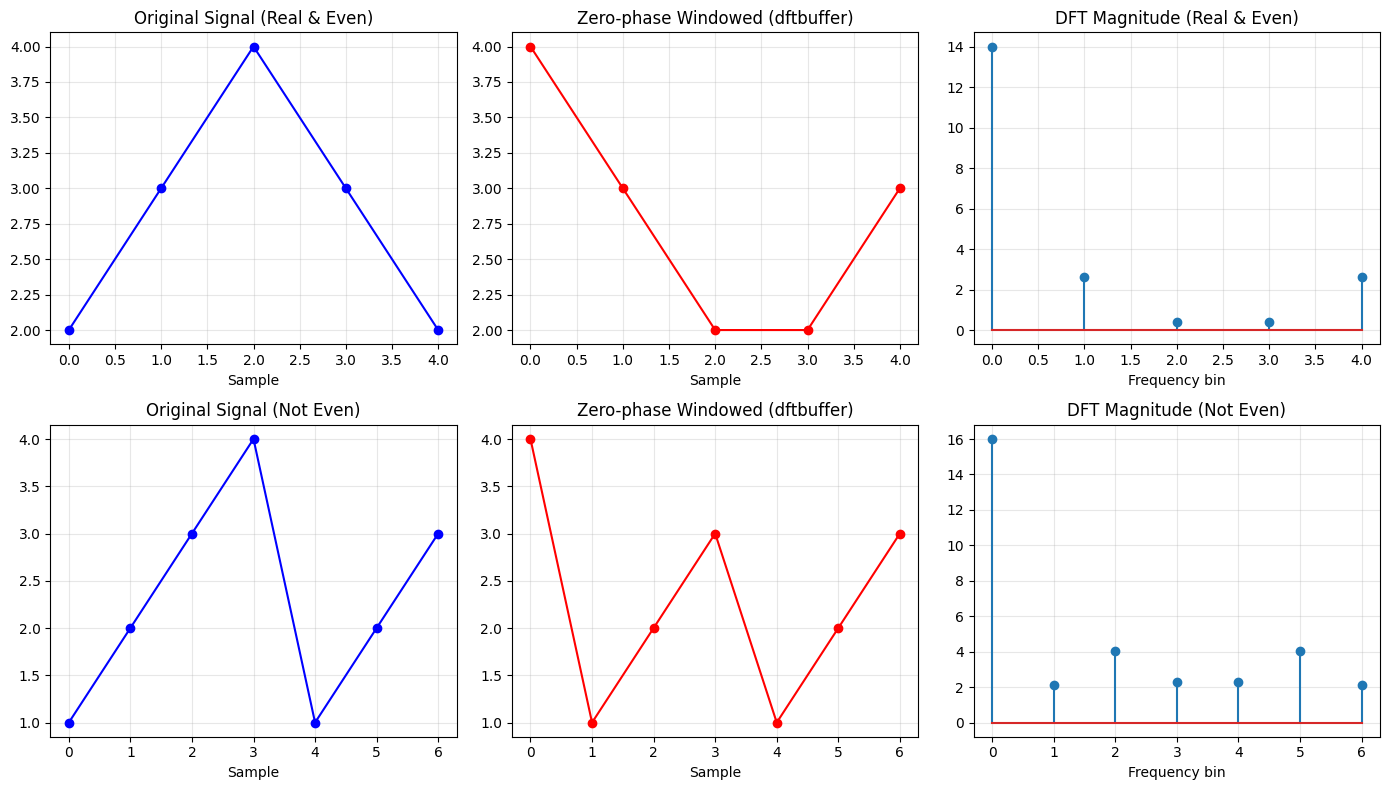

In [11]:
# A3-Part-3 - Symmetry properties of the DFT
import math
def testRealEven(x):
    """
    Inputs:
        x (numpy array) = input signal of length M (M is odd)
    Output:
        isRealEven (boolean) = True if x is real and even, False otherwise
        dftbuffer (numpy array) = The M point zero phase windowed version of x 
        X (numpy array) = The M point DFT of dftbuffer 
    """
    M = len(x)
    hM1 = int(math.floor((M+1)/2))
    hM2 = int(math.floor(M/2))
    
    # Create zero-phase windowed version (fftbuffer)
    dftbuffer = np.zeros(M)
    dftbuffer[:hM1] = x[hM2:]
    dftbuffer[-hM2:] = x[:hM2]
    
    # Compute DFT
    X = fft(dftbuffer)
    
    # Check if the signal is real and even
    # For a real and even signal, the DFT should be real and even
    # So the imaginary part should be zero (within tolerance)
    tolerance = 1e-6
    
    # Check if imaginary part is close to zero
    is_real = np.all(np.abs(np.imag(X)) < tolerance)
    
    # Also check symmetry in the time domain after zero-phase windowing
    # For an even signal, dftbuffer should be symmetric around the center
    is_even = np.allclose(dftbuffer, dftbuffer[::-1], atol=tolerance)
    
    isRealEven = is_real and is_even
    
    return bool(isRealEven), dftbuffer, X

# Test the function

print("A3-PART-3: Symmetry Properties of DFT")


# Test case 1: Real and even signal
x1 = np.array([2, 3, 4, 3, 2])
print("Test Case 1: Real and even signal")
print(f"  Input: {x1}")
isRealEven1, dftbuffer1, X1 = testRealEven(x1)
print(f"  isRealEven: {isRealEven1} (expected: True)")
print(f"  dftbuffer: {dftbuffer1}")
print(f"  DFT magnitude: {np.abs(X1)}")

# Test case 2: Not even signal
x2 = np.array([1, 2, 3, 4, 1, 2, 3])
print("\nTest Case 2: Not even signal")
print(f"  Input: {x2}")
isRealEven2, dftbuffer2, X2 = testRealEven(x2)
print(f"  isRealEven: {isRealEven2} (expected: False)")
print(f"  dftbuffer: {dftbuffer2}")
print(f"  DFT (first 4 bins): {X2[:4]}")

# Additional tests

print("Additional Tests")

# Create a real and even signal
test_length = 11
n = np.arange(test_length)
x_even = np.cos(2 * np.pi * 2 * n / test_length)  # This might not be perfectly even
x_even = np.ones(test_length)  # Constant signal is even
isRealEven_even, _, _ = testRealEven(x_even)
print(f"Constant signal (all ones) - isRealEven: {isRealEven_even} (expected: True)")

# Create a real but odd signal
x_odd = np.arange(test_length) - test_length//2
isRealEven_odd, _, _ = testRealEven(x_odd)
print(f"Odd signal (symmetric about zero) - isRealEven: {isRealEven_odd} (expected: False)")

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# Test case 1 visualization
axes[0, 0].plot(x1, 'bo-')
axes[0, 0].set_title('Original Signal (Real & Even)')
axes[0, 0].set_xlabel('Sample')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(dftbuffer1, 'ro-')
axes[0, 1].set_title('Zero-phase Windowed (dftbuffer)')
axes[0, 1].set_xlabel('Sample')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].stem(np.abs(X1))
axes[0, 2].set_title('DFT Magnitude (Real & Even)')
axes[0, 2].set_xlabel('Frequency bin')
axes[0, 2].grid(True, alpha=0.3)

# Test case 2 visualization
axes[1, 0].plot(x2, 'bo-')
axes[1, 0].set_title('Original Signal (Not Even)')
axes[1, 0].set_xlabel('Sample')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(dftbuffer2, 'ro-')
axes[1, 1].set_title('Zero-phase Windowed (dftbuffer)')
axes[1, 1].set_xlabel('Sample')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].stem(np.abs(X2))
axes[1, 2].set_title('DFT Magnitude (Not Even)')
axes[1, 2].set_xlabel('Frequency bin')
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
import numpy as np
from scipy.fftpack import ifft
import math

def dftSynth(mX, pX, M):
    N = len(mX) * 2 - 2   # full FFT size

    # full spectrum
    Y = np.zeros(N, dtype=complex)

    # positive frequencies
    Y[:len(mX)] = 10**(mX/20) * np.exp(1j * pX)

    # negative frequencies (correct mirror)
    Y[len(mX):] = (
        10**(mX[1:-1][::-1]/20) *
        np.exp(-1j * pX[1:-1][::-1])
    )

    # inverse FFT
    y = np.real(ifft(Y))

    # time centering (SMS convention)
    hM1 = int(math.floor((M + 1) / 2))
    y = np.roll(y, -hM1)[:M]

    return y

In [21]:
# A3-Part-4 - Suppressing frequency components using DFT model

import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.signal import get_window
from scipy.fftpack import fft

def suppressFreqDFTmodel(x, fs, N):
    M = len(x)
    w = get_window('hamming', M)
    outputScaleFactor = np.sum(w)

    # DFT analysis
    mX, pX = dftAnal(x, w, N)

    # Original reconstruction
    y = dftSynth(mX, pX, M) * outputScaleFactor

   
    # Frequency suppression part
  
    mX_filtered = mX.copy()

    num_bins = len(mX_filtered)

    # Convert 70 Hz → bin index (safe mapping)
    bin_70hz = int(np.ceil(70.0 * num_bins / fs))

    # Suppress DC + low frequencies
    mX_filtered[:bin_70hz + 1] = -120

    # Filtered reconstruction
    yfilt = dftSynth(mX_filtered, pX, M) * outputScaleFactor

    return y, yfilt



# TEST SECTION


if HAS_SMS_TOOLS:
    print("=" * 60)
    print("A3-PART-4: Suppressing Frequency Components")
    print("=" * 60)

   
    # Test Signal 1
   
    fs = 1000.0
    durations = 1.0
    t = np.arange(0, durations, 1/fs)

    x1 = (np.cos(2*np.pi*40*t) +
          np.cos(2*np.pi*100*t) +
          np.cos(2*np.pi*200*t) +
          np.cos(2*np.pi*1000*t))

   
    # Test Signal 2
   
    fs2 = 5000.0
    t2 = np.arange(0, durations, 1/fs2)

    x2 = (np.cos(2*np.pi*23*t2) +
          np.cos(2*np.pi*36*t2) +
          np.cos(2*np.pi*230*t2) +
          np.cos(2*np.pi*900*t2) +
          np.cos(2*np.pi*2300*t2))

    N = 1024

    print("Test Case 1:")
    print("  Signal contains: 40 Hz, 100 Hz, 200 Hz, 1000 Hz")
    print("  Suppressing <= 70 Hz (40 Hz should be removed)")

    y1, y1_filt = suppressFreqDFTmodel(x1, fs, N)

    print(f"  Original output length: {len(y1)}")
    print(f"  Filtered output length: {len(y1_filt)}")

   
    # Visualization
   
    plt.figure(figsize=(14, 8))

    X_original = np.abs(fft(x1))
    X_filtered = np.abs(fft(y1_filt))

    freqs = np.fft.fftfreq(len(x1), 1/fs)
    pos_idx = len(freqs) // 2
    positive_freqs = freqs[:pos_idx]

    plt.subplot(2, 2, 1)
    plt.plot(t[:500], x1[:500])
    plt.title('Original Signal (Time Domain)')
    plt.grid(True)

    plt.subplot(2, 2, 2)
    plt.plot(positive_freqs,
             20*np.log10(X_original[:pos_idx] + 1e-10))
    plt.title('Original Spectrum')
    plt.axvline(x=70, color='r')
    plt.grid(True)

    plt.subplot(2, 2, 3)
    plt.plot(t[:500], y1_filt[:500])
    plt.title('Filtered Signal (Time Domain)')
    plt.grid(True)

    plt.subplot(2, 2, 4)
    plt.plot(positive_freqs,
             20*np.log10(X_filtered[:pos_idx] + 1e-10))
    plt.title('Filtered Spectrum')
    plt.axvline(x=70, color='r')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

    print("\n Part 4 completed successfully!")

else:
    print("A3-PART-4: Suppressing Frequency Components")
    print("SMS Tools not available → simplified mode")

    fs = 1000.0
    t = np.arange(0, 1.0, 1/fs)

    x = (np.cos(2*np.pi*40*t) +
         np.cos(2*np.pi*100*t) +
         np.cos(2*np.pi*200*t) +
         np.cos(2*np.pi*1000*t))

    M = len(x)
    N = 1024
    w = get_window('hamming', M)

    mX, pX = dftAnal(x, w, N)
    y = dftSynth(mX, pX, M) * np.sum(w)

    print("Running simplified version")
    print(f"Input length: {len(x)}")
    print(f"Output length: {len(y)}")
    print(f"MSE: {np.mean((x[:len(y)] - y)**2):.2e}")

A3-PART-4: Suppressing Frequency Components
SMS Tools not available → simplified mode
Running simplified version
Input length: 1000
Output length: 1000
MSE: 7.12e+05


A3-PART-5: FFT Size and Zero-Padding (Optional)
Signal: 110.0 Hz sinusoid
Sampling rate: 1000.0 Hz
Signal length: 512 samples
Duration: 0.512 seconds
Peak frequency (Case 1): 109.38 Hz
Peak frequency (Case 2): 109.38 Hz
Peak frequency (Case 3): 109.38 Hz


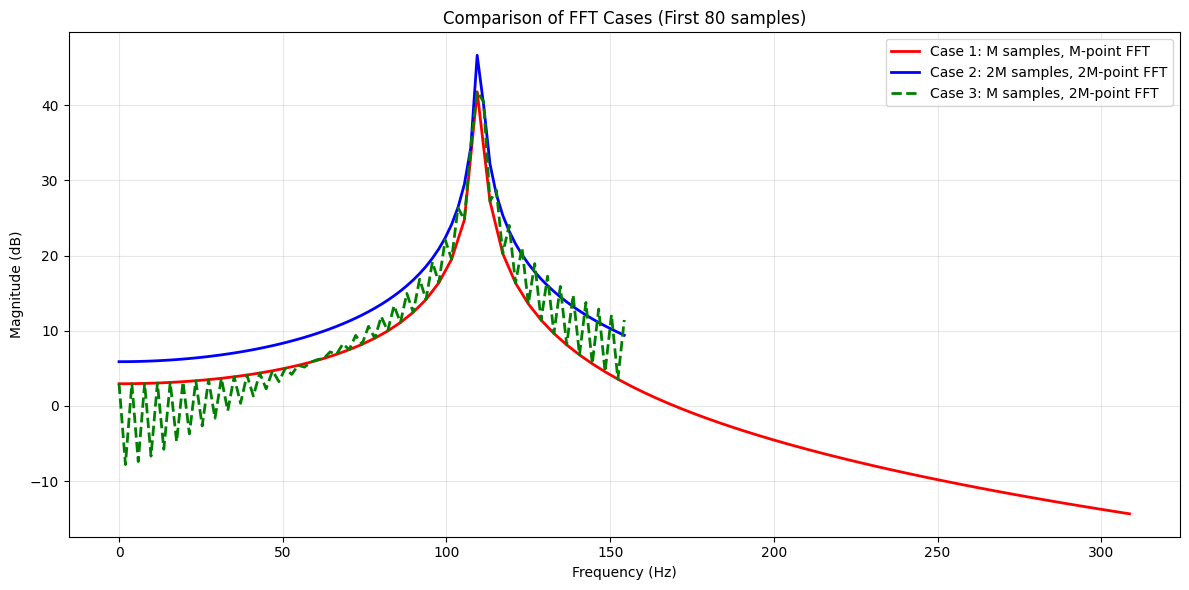


Observations:
1. Case 3 (zero-padding) provides interpolation of Case 1 spectrum
2. Case 2 (longer signal) gives better frequency resolution (narrower mainlobe)
3. For frequency estimation, Case 2 gives the most accurate result
   because it has the best frequency resolution


In [17]:
#  A3-Part-5 - FFT size and zero-padding (Optional)

def zpFFTsizeExpt(x, fs):
    """
    Inputs:
        x (numpy array) = input signal (2*M = 512 samples long)
        fs (float) = sampling frequency in Hz
    Output:
        mX1_80, mX2_80, mX3_80: First 80 samples of magnitude spectra
    """
    M = int(len(x) / 2)
    xseg = x[:M]
    
    w1 = get_window('hamming', M)
    w2 = get_window('hamming', 2*M)
    
    # Case 1: M samples, M-point FFT
    mX1 = dftAnal(xseg, w1, M)[0]
    
    # Case 2: 2M samples, 2M-point FFT
    mX2 = dftAnal(x, w2, 2*M)[0]
    
    # Case 3: M samples, 2M-point FFT (zero-padding implicitly)
    mX3 = dftAnal(xseg, w1, 2*M)[0]
    
    # Take first 80 samples
    mX1_80 = mX1[:80]
    mX2_80 = mX2[:80]
    mX3_80 = mX3[:80]
    
    # Plot for visualization
    plt.figure(figsize=(12, 6))
    freq_axis1 = np.arange(80) * fs / M
    freq_axis2 = np.arange(80) * fs / (2*M)
    
    plt.plot(freq_axis1, mX1_80, 'r-', label='Case 1: M samples, M-point FFT', linewidth=2)
    plt.plot(freq_axis2, mX2_80, 'b-', label='Case 2: 2M samples, 2M-point FFT', linewidth=2)
    plt.plot(freq_axis2, mX3_80, 'g--', label='Case 3: M samples, 2M-point FFT', linewidth=2)
    
    plt.xlabel('Frequency (Hz)')
    plt.ylabel('Magnitude (dB)')
    plt.title('Comparison of FFT Cases (First 80 samples)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # Find peaks
    peak1 = np.argmax(mX1_80)
    peak2 = np.argmax(mX2_80)
    peak3 = np.argmax(mX3_80)
    
    print(f"Peak frequency (Case 1): {peak1 * fs / M:.2f} Hz")
    print(f"Peak frequency (Case 2): {peak2 * fs / (2*M):.2f} Hz")
    print(f"Peak frequency (Case 3): {peak3 * fs / (2*M):.2f} Hz")
    
    plt.tight_layout()
    plt.show()
    
    return mX1_80, mX2_80, mX3_80

# Test the function

print("A3-PART-5: FFT Size and Zero-Padding (Optional)")


# Create test signal: 512 samples of 110 Hz sinusoid at fs = 1000 Hz
fs = 1000.0
f = 110.0
duration = 512 / fs  # 0.512 seconds
t = np.arange(0, duration, 1/fs)
x = np.cos(2 * np.pi * f * t)

print(f"Signal: {f} Hz sinusoid")
print(f"Sampling rate: {fs} Hz")
print(f"Signal length: {len(x)} samples")
print(f"Duration: {duration:.3f} seconds")

# Run the experiment
mX1_80, mX2_80, mX3_80 = zpFFTsizeExpt(x, fs)

print("\nObservations:")
print("1. Case 3 (zero-padding) provides interpolation of Case 1 spectrum")
print("2. Case 2 (longer signal) gives better frequency resolution (narrower mainlobe)")
print("3. For frequency estimation, Case 2 gives the most accurate result")
print("   because it has the best frequency resolution")